# Análise do IPPRA

A seed 42 é usada na análise paralela. A PCA, a rotação Varimax e os demais cálculos são determinísticos para uma mesma matriz de entrada e versões compatíveis das bibliotecas.


## 1. Instalação e bibliotecas

versões fixadas das bibliotecas para que cálculos e formatos de saída sejam consistentes entre execuções.


In [7]:
# leitura de arquivos Excel.
%pip -q install openpyxl==3.1.5

# .
import hashlib
import json
import random
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.stats import chi2

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("SciPy:", scipy.__version__)




NumPy: 2.1.3
pandas: 2.2.3
SciPy: 1.16.3


## 2. Parâmetros da análise

.


In [8]:
# Define a semente global e a semente do gerador NumPy.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Lista dos 23 indicadores incluídos na análise.
VARIAVEIS = [
    "qi04", "qa04", "piaf", "poea_af", "idhm_e", "idhm_l", "idhm_r",
    "gin", "t_banagua", "t_luz", "assoc", "icms_t", "pr_af", "exis",
    "pap_pi", "pap_us", "pap_m", "pipo", "rlt", "appt", "aurt", "bpm", "reg",
]

# Aba que contém uma linha por município e as variáveis quantitativas.
NOME_ABA = "Dados"
N_SIMULACOES = 1000
PASTA_RESULTADOS = Path("/content/resultados_ippra")
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

print(f"Seed: {SEED} | Variáveis: {len(VARIAVEIS)} | Simulações: {N_SIMULACOES}")


Seed: 42 | Variáveis: 23 | Simulações: 1000


## 3. Carregamento da planilha




In [9]:
# Abre a janela de seleção de arquivo do Google Colab.
from google.colab import files

arquivos_enviados = files.upload()
arquivos_excel = [nome for nome in arquivos_enviados if nome.lower().endswith((".xlsx", ".xls"))]
if len(arquivos_excel) != 1:
    raise ValueError("Envie exatamente um arquivo Excel para esta análise.")

ARQUIVO_DADOS = Path(arquivos_excel[0])
abas = pd.ExcelFile(ARQUIVO_DADOS).sheet_names
if NOME_ABA not in abas:
    raise ValueError(f"A aba {NOME_ABA!r} não existe. Abas encontradas: {abas}")

dados_brutos = pd.read_excel(ARQUIVO_DADOS, sheet_name=NOME_ABA, engine="openpyxl")
print("Arquivo:", ARQUIVO_DADOS.name)
print("Dimensão da aba:", dados_brutos.shape)
display(dados_brutos.head())


Saving dataset_IPPRA.xlsx to dataset_IPPRA (1).xlsx
Arquivo: dataset_IPPRA (1).xlsx
Dimensão da aba: (90, 24)


,municipios,qi04,qa04,piaf,poea_af,idhm_e,idhm_l,idhm_r,gin,t_banagua,...,exis,pap_pi,pap_us,pap_m,pipo,rlt,appt,aurt,bpm,reg
0,ANG,226,3606.6288,58.571429,669,0.605,0.846,0.740,0.50,95.45,...,6,46047.193000,7877.015000,2054.649000,3.095238,4996.2745,3437.6262,3940.8638,325,10.000000
1,APE,282,5038.5767,70.486111,483,0.631,0.785,0.670,0.43,99.52,...,1,375.757890,1664.218981,2039.976871,0.347222,781.8774,167.0740,27.9028,87,3.423631
2,ARA,411,5791.9065,47.108434,673,0.617,0.839,0.714,0.54,94.42,...,5,818.153600,11417.038576,349.975576,0.843373,4466.8994,1438.5011,0.0000,130,0.221243
3,ARE,108,2296.3574,42.857143,86,0.566,0.823,0.686,0.48,98.20,...,5,0.000000,8511.866200,8511.866200,14.285714,1703.6262,507.1707,282.8648,89,5.000000
4,ARM,10,191.6060,70.000000,31,0.624,0.824,0.750,0.51,96.31,...,5,1387.260028,4094.150231,3759.161159,5.000000,393.7168,1.9382,7.0568,1,0.000000


## 4. Verificação das colunas e preparação dos registros

Esta etapa confirma a presença da coluna de município e dos 23 indicadores. Siglas repetidas representam registros distintos e recebem sufixos sequenciais (`CAB`, `CAB_1`, por exemplo). O código não elimina linhas por causa de uma sigla duplicada.


In [10]:
# Confere se a planilha possui todos os campos necessários.
colunas_necessarias = ["municipios", *VARIAVEIS]
colunas_ausentes = [coluna for coluna in colunas_necessarias if coluna not in dados_brutos.columns]
if colunas_ausentes:
    raise ValueError(f"Colunas necessárias ausentes: {colunas_ausentes}")

# Mantém somente município e indicadores definidos para a análise.
dados = dados_brutos[colunas_necessarias].dropna(how="all").copy()
dados = dados.loc[dados["municipios"].notna()].copy()
dados["municipios_original"] = dados["municipios"].astype(str).str.strip()

# Gera uma chave única para cada linha sem alterar a sigla original.
contagens = {}
ids = []
for sigla in dados["municipios_original"]:
    ocorrencia = contagens.get(sigla, 0)
    ids.append(sigla if ocorrencia == 0 else f"{sigla}_{ocorrencia}")
    contagens[sigla] = ocorrencia + 1
dados["municipio_id"] = ids

# Converte cada indicador para formato numérico e sinaliza texto inesperado.
for variavel in VARIAVEIS:
    original = dados[variavel]
    numerico = pd.to_numeric(original, errors="coerce")
    invalidos = original.notna() & numerico.isna()
    if invalidos.any():
        linhas_excel = (dados.index[invalidos] + 2).tolist()
        raise ValueError(f"Valores não numéricos em {variavel}, linhas Excel: {linhas_excel}")
    dados[variavel] = numerico

# A análise usa a mesma matriz de casos para todos os indicadores; por isso, não há imputação automática.
faltantes = dados[VARIAVEIS].isna().sum()
if faltantes.any():
    raise ValueError(f"Há valores ausentes: {faltantes[faltantes > 0].to_dict()}")
if dados["municipio_id"].duplicated().any():
    raise AssertionError("Os identificadores municipais ainda não são únicos.")

siglas_repetidas = dados.loc[dados["municipios_original"].duplicated(keep=False), "municipios_original"].drop_duplicates().tolist()
print(f"Registros: {len(dados)} | Indicadores: {len(VARIAVEIS)}")
print("Siglas repetidas:", siglas_repetidas)
display(dados[["municipios_original", "municipio_id"]].head(10))


Registros: 90 | Indicadores: 23
Siglas repetidas: ['CAB', 'SAL', 'TER']


,municipios_original,municipio_id
0,ANG,ANG
1,APE,APE
2,ARA,ARA
3,ARE,ARE
4,ARM,ARM
5,ARR,ARR
6,BAD,BAD
7,BAM,BAM
8,BEL,BEL
9,BOA,BOA


## 5. Estatísticas descritivas e padronização

As estatísticas descrevem a distribuição de cada variável. O escore z subtrai a média e divide pelo desvio-padrão amostral, colocando indicadores medidos em escalas diferentes em uma escala comparável antes da análise de correlações.


In [11]:
# Calcula estatísticas descritivas para os 23 indicadores.
estatisticas_descritivas = dados[VARIAVEIS].describe().T
estatisticas_descritivas["ausentes"] = dados[VARIAVEIS].isna().sum()
display(estatisticas_descritivas.round(4))

# Usa o desvio-padrão amostral, como na função scale() padrão do R.
medias = dados[VARIAVEIS].mean()
desvios = dados[VARIAVEIS].std(ddof=1)
if (desvios == 0).any():
    raise ValueError(f"Indicadores sem variação: {desvios[desvios == 0].index.tolist()}")
z = (dados[VARIAVEIS] - medias) / desvios
matriz_r = z.corr().to_numpy()
print("Matriz de correlações:", matriz_r.shape)


,count,mean,std,min,25%,50%,75%,max,ausentes
qi04,90.0,4.759111e+02,5.367100e+02,1.0000,135.0000,2.865000e+02,5.840000e+02,3.421000e+03,0
qa04,90.0,9.705764e+03,1.058646e+04,10.7093,2301.8035,5.188948e+03,1.420391e+04,5.937996e+04,0
piaf,90.0,6.205690e+01,1.361240e+01,36.3636,52.9649,6.170440e+01,7.046260e+01,9.275360e+01,0
poea_af,90.0,1.019389e+03,1.464873e+03,0.0000,264.0000,6.070000e+02,1.174250e+03,9.652000e+03,0
idhm_e,90.0,6.196000e-01,5.600000e-02,0.4360,0.5900,6.240000e-01,6.512000e-01,7.730000e-01,0
idhm_l,90.0,8.159000e-01,1.830000e-02,0.7820,0.8040,8.120000e-01,8.295000e-01,8.550000e-01,0
idhm_r,90.0,7.044000e-01,4.220000e-02,0.6180,0.6822,6.985000e-01,7.228000e-01,8.870000e-01,0
gin,90.0,4.908000e-01,4.140000e-02,0.4200,0.4700,4.900000e-01,5.100000e-01,6.200000e-01,0
t_banagua,90.0,9.462060e+01,4.590300e+00,74.7500,92.2375,9.642500e+01,9.794750e+01,9.983000e+01,0
t_luz,90.0,8.825520e+01,9.713000e+00,43.1627,84.9414,9.122060e+01,9.390680e+01,1.000000e+02,0


Matriz de correlações: (23, 23)


## 6. KMO, MSA e teste de Bartlett

O KMO geral e o MSA individual comparam correlações simples às correlações parciais. Valores maiores indicam que a estrutura de correlações pode ser resumida com mais facilidade. O teste de Bartlett avalia a hipótese de que a matriz de correlações seja uma matriz identidade; um resultado significativo indica que há associações entre os indicadores.


In [12]:
# Calcula KMO geral e medida de adequação amostral (MSA) para cada variável.
inversa_r = np.linalg.pinv(matriz_r)
escala_parcial = np.sqrt(np.outer(np.diag(inversa_r), np.diag(inversa_r)))
correlacoes_parciais = -inversa_r / escala_parcial
np.fill_diagonal(correlacoes_parciais, 0)
correlacoes = matriz_r.copy()
np.fill_diagonal(correlacoes, 0)
r_quadrado = correlacoes**2
p_quadrado = correlacoes_parciais**2
msa = r_quadrado.sum(axis=0) / (r_quadrado.sum(axis=0) + p_quadrado.sum(axis=0))
kmo_geral = float(r_quadrado.sum() / (r_quadrado.sum() + p_quadrado.sum()))

# Calcula Bartlett pela aproximação qui-quadrado da matriz de correlações.
n, p = z.shape
sinal_det, log_determinante = np.linalg.slogdet(matriz_r)
if sinal_det <= 0:
    raise ValueError("A matriz de correlações não possui determinante positivo.")
bartlett_chi2 = -(n - 1 - (2 * p + 5) / 6) * log_determinante
bartlett_gl = p * (p - 1) // 2
bartlett_p = float(chi2.sf(bartlett_chi2, bartlett_gl))

msa_tabela = pd.DataFrame({"variavel": VARIAVEIS, "MSA": msa}).sort_values("MSA")
print(f"KMO geral: {kmo_geral:.4f}")
print(f"Bartlett: qui-quadrado({bartlett_gl}) = {bartlett_chi2:.3f}; p = {bartlett_p:.4g}")
display(msa_tabela.round(4))


KMO geral: 0.6970
Bartlett: qui-quadrado(253) = 1234.996; p = 6.648e-129


,variavel,MSA
16,pap_m,0.4032
8,t_banagua,0.4145
22,reg,0.4908
9,t_luz,0.5653
15,pap_us,0.5681
21,bpm,0.6423
17,pipo,0.6552
14,pap_pi,0.6611
18,rlt,0.6710
12,pr_af,0.6792


## 7. Componentes principais e análise paralela

A PCA decompõe a matriz de correlações em autovalores e autovetores. A análise paralela compara cada autovalor observado ao percentil 95 dos autovalores obtidos em matrizes aleatórias sem correlação. Retemos os componentes observados acima desse limite. O critério de Kaiser (autovalor maior que 1) também é informado para comparação, mas não determina a retenção usada no índice.


In [13]:
# Obtém e ordena os autovalores observados do maior para o menor.
autovalores, autovetores = np.linalg.eigh(matriz_r)
ordem = np.argsort(autovalores)[::-1]
autovalores = autovalores[ordem]
autovetores = autovetores[:, ordem]

# Simula matrizes não correlacionadas com o mesmo tamanho amostral e número de variáveis.
gerador = np.random.default_rng(SEED)
autovalores_simulados = np.empty((N_SIMULACOES, p))
for simulacao in range(N_SIMULACOES):
    matriz_aleatoria = gerador.normal(size=(n, p))
    correlacao_aleatoria = np.corrcoef(matriz_aleatoria, rowvar=False)
    autovalores_simulados[simulacao] = np.linalg.eigvalsh(correlacao_aleatoria)[::-1]
limite_95 = np.quantile(autovalores_simulados, 0.95, axis=0)
media_simulada = autovalores_simulados.mean(axis=0)

# Retém os autovalores observados superiores ao percentil 95 aleatório.
k = int(np.sum(autovalores > limite_95))
if k < 1:
    raise ValueError("A análise paralela não reteve componentes.")
proporcao_variancia = autovalores / autovalores.sum()
variancia_acumulada = np.cumsum(proporcao_variancia)

tabela_autovalores = pd.DataFrame({
    "componente": np.arange(1, p + 1),
    "autovalor": autovalores,
    "variancia_percentual": proporcao_variancia * 100,
    "variancia_acumulada_percentual": variancia_acumulada * 100,
    "limite_95_aleatorio": limite_95,
    "retido_analise_paralela": autovalores > limite_95,
    "retido_kaiser_maior_1": autovalores > 1,
})
print(f"Componentes retidos pela análise paralela: {k}")
print(f"Componentes com autovalor > 1: {int(np.sum(autovalores > 1))}")
print(f"Variância acumulada dos retidos: {variancia_acumulada[k - 1] * 100:.2f}%")
display(tabela_autovalores.head(10).round(4))


Componentes retidos pela análise paralela: 4
Componentes com autovalor > 1: 7
Variância acumulada dos retidos: 57.71%


,componente,autovalor,variancia_percentual,variancia_acumulada_percentual,limite_95_aleatorio,retido_analise_paralela,retido_kaiser_maior_1
0,1,5.3127,23.0987,23.0987,2.2320,True,True
1,2,3.9018,16.9642,40.0630,1.9925,True,True
2,3,2.1442,9.3226,49.3856,1.8221,True,True
3,4,1.9150,8.3259,57.7115,1.6844,True,True
4,5,1.3501,5.8702,63.5817,1.5736,False,True
5,6,1.1739,5.1039,68.6857,1.4648,False,True
6,7,1.0317,4.4855,73.1712,1.3714,False,True
7,8,0.9373,4.0753,77.2465,1.2796,False,False
8,9,0.7766,3.3766,80.6231,1.1995,False,False
9,10,0.6970,3.0302,83.6533,1.1204,False,False


## 8. Rotação Varimax, cargas e comunalidades

A rotação Varimax é ortogonal e procura uma estrutura em que cada variável tenha cargas mais concentradas em alguns componentes, facilitando a interpretação. As comunalidades são a soma dos quadrados das cargas retidas para cada indicador.


In [14]:
# Função Varimax com normalização Kaiser para equilibrar a influência das variáveis.
def rotacao_varimax(cargas, tolerancia=1e-7, max_iteracoes=500):
    escala = np.sqrt(np.sum(cargas**2, axis=1))
    escala[escala == 0] = 1.0
    normalizadas = cargas / escala[:, None]
    n_variaveis, n_fatores = normalizadas.shape
    rotacao = np.eye(n_fatores)
    criterio_anterior = 0.0

    for _ in range(max_iteracoes):
        cargas_rotacionadas = normalizadas @ rotacao
        alvo = normalizadas.T @ (
            cargas_rotacionadas**3
            - cargas_rotacionadas @ np.diag(np.sum(cargas_rotacionadas**2, axis=0)) / n_variaveis
        )
        u, valores_singulares, vh = np.linalg.svd(alvo, full_matrices=False)
        rotacao_nova = u @ vh
        criterio = float(valores_singulares.sum())
        rotacao = rotacao_nova
        if criterio_anterior and criterio / criterio_anterior < 1 + tolerancia:
            break
        criterio_anterior = criterio

    cargas_finais = (normalizadas @ rotacao) * escala[:, None]
    return cargas_finais, rotacao

# Calcula cargas iniciais e aplica a rotação nos k componentes retidos.
cargas_iniciais = autovetores[:, :k] * np.sqrt(autovalores[:k])[None, :]
cargas_rotacionadas, matriz_rotacao = rotacao_varimax(cargas_iniciais)

# O sinal dos eixos é arbitrário; orientamos cada componente para manter resultados legíveis.
for j in range(k):
    indice_maior = int(np.argmax(np.abs(cargas_rotacionadas[:, j])))
    if cargas_rotacionadas[indice_maior, j] < 0:
        cargas_rotacionadas[:, j] *= -1
        matriz_rotacao[:, j] *= -1

nomes_fatores = [f"F{i}" for i in range(1, k + 1)]
tabela_cargas = pd.DataFrame(cargas_rotacionadas, index=VARIAVEIS, columns=nomes_fatores)
tabela_cargas.index.name = "variavel"
tabela_cargas["comunalidade"] = np.sum(cargas_rotacionadas**2, axis=1)
display(tabela_cargas.round(3))


,F1,F2,F3,F4,comunalidade
variavel,,,,,
qi04,0.890,-0.008,0.262,-0.124,0.877
qa04,0.917,-0.071,0.063,-0.152,0.873
piaf,0.057,-0.140,0.803,-0.052,0.670
poea_af,0.733,0.112,0.504,-0.035,0.805
idhm_e,-0.206,0.670,-0.422,-0.175,0.700
idhm_l,-0.009,0.858,0.029,0.088,0.745
idhm_r,-0.058,0.899,-0.248,0.014,0.873
gin,0.206,0.742,-0.127,0.089,0.617
t_banagua,0.060,0.140,-0.231,-0.412,0.246


## 9. Escores fatoriais

Para cada município, os escores são obtidos pela combinação linear das variáveis padronizadas com as cargas rotacionadas. Eles representam a posição relativa do município em cada dimensão resumida pelos componentes.


In [15]:
# Multiplica a matriz de dados padronizados pelas cargas rotacionadas.
escores = z.to_numpy() @ cargas_rotacionadas
nomes_fatores = [f"F{i}" for i in range(1, k + 1)]
tabela_escores = pd.DataFrame(escores, columns=nomes_fatores)
tabela_escores.insert(0, "municipio_id", dados["municipio_id"].to_numpy())
tabela_escores.insert(0, "municipios", dados["municipios_original"].to_numpy())
display(tabela_escores.head(10).round(3))


,municipios,municipio_id,F1,F2,F3,F4
0,ANG,ANG,1.313,5.247,1.289,5.757
1,APE,APE,-4.047,-5.410,1.558,-3.674
2,ARA,ARA,-2.227,1.942,-2.641,-0.343
3,ARE,ARE,-3.575,-1.333,-3.486,-0.770
4,ARM,ARM,-5.017,2.538,-2.201,-1.694
5,ARR,ARR,-4.214,-0.044,0.613,-0.677
6,BAD,BAD,-0.045,1.575,-4.043,0.839
7,BAM,BAM,0.518,2.135,-0.350,-0.765
8,BEL,BEL,-5.543,-6.264,-0.956,-2.977
9,BOA,BOA,3.335,-3.115,2.803,-2.142


## 10. GI, IPPRA e quartis

O GI é calculado como média ponderada dos escores, com pesos proporcionais à variância rotacionada de cada fator. O IPPRA é uma interpolação min–máx: o menor GI recebe 0 e o maior recebe 100. Os quartis agrupam os municípios em quatro faixas da distribuição do IPPRA.


In [16]:
# A variância rotacionada de cada fator é a soma dos quadrados das suas cargas.
variancia_rotacionada = np.sum(cargas_rotacionadas**2, axis=0)
pesos = variancia_rotacionada / variancia_rotacionada.sum()

# Calcula a média ponderada e verifica se cada GI está dentro da faixa dos escores usados.
gi = escores @ pesos
menor_escore = escores.min(axis=1)
maior_escore = escores.max(axis=1)
gi_dentro_limites = (gi >= menor_escore - 1e-10) & (gi <= maior_escore + 1e-10)
if not gi_dentro_limites.all():
    raise AssertionError("Foi encontrado GI fora dos limites dos escores fatoriais.")

# Converte o GI para uma escala relativa de 0 a 100.
intervalo_gi = gi.max() - gi.min()
if intervalo_gi == 0:
    raise ValueError("O GI não varia; não é possível interpolar para 0–100.")
ippra = 100 * (gi - gi.min()) / intervalo_gi

# Ordena os municípios e constrói quartis do menor para o maior IPPRA.
resultado_ippra = pd.DataFrame({
    "municipios": dados["municipios_original"].to_numpy(),
    "municipio_id": dados["municipio_id"].to_numpy(),
    "GI": gi,
    "IPPRA": ippra,
    "menor_escore": menor_escore,
    "maior_escore": maior_escore,
    "GI_dentro_limites": gi_dentro_limites,
})
resultado_ippra["quartil"] = pd.qcut(
    resultado_ippra["IPPRA"].rank(method="first"), 4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)
resultado_ippra = resultado_ippra.sort_values("IPPRA", ascending=False).reset_index(drop=True)
resultado_ippra["ranking"] = np.arange(1, len(resultado_ippra) + 1)

pesos_tabela = pd.DataFrame({
    "fator": nomes_fatores,
    "variancia_rotacionada": variancia_rotacionada,
    "peso": pesos,
})
print("Soma dos pesos:", pesos.sum())
print("Todos os GI respeitam os limites:", bool(gi_dentro_limites.all()))
display(pesos_tabela.round(4))
display(resultado_ippra[["municipios", "municipio_id", "GI", "IPPRA", "ranking", "quartil"]].head(10).round(3))


Soma dos pesos: 1.0
Todos os GI respeitam os limites: True


,fator,variancia_rotacionada,peso
0,F1,4.3302,0.3262
1,F2,3.4251,0.2580
2,F3,2.9560,0.2227
3,F4,2.5624,0.1930


,municipios,municipio_id,GI,IPPRA,ranking,quartil
0,CAP,CAP,8.985,100.000,1,Q4
1,NOF,NOF,8.983,99.982,2,Q4
2,TER,TER,6.939,84.500,3,Q4
3,SAR,SAR,6.071,77.920,4,Q4
4,CAC,CAC,4.939,69.341,5,Q4
5,PAT,PAT,4.809,68.360,6,Q4
6,PET,PET,4.197,63.723,7,Q4
7,VAL,VAL,3.822,60.881,8,Q4
8,SUM,SUM,3.752,60.347,9,Q4
9,ITP,ITP,3.647,59.555,10,Q4


## 11. Gráfico scree e limite da análise paralela

A linha azul apresenta os autovalores da matriz observada. A linha vermelha tracejada mostra o percentil 95 dos autovalores simulados. Os componentes retidos são aqueles em que a curva observada permanece acima do limite simulado.


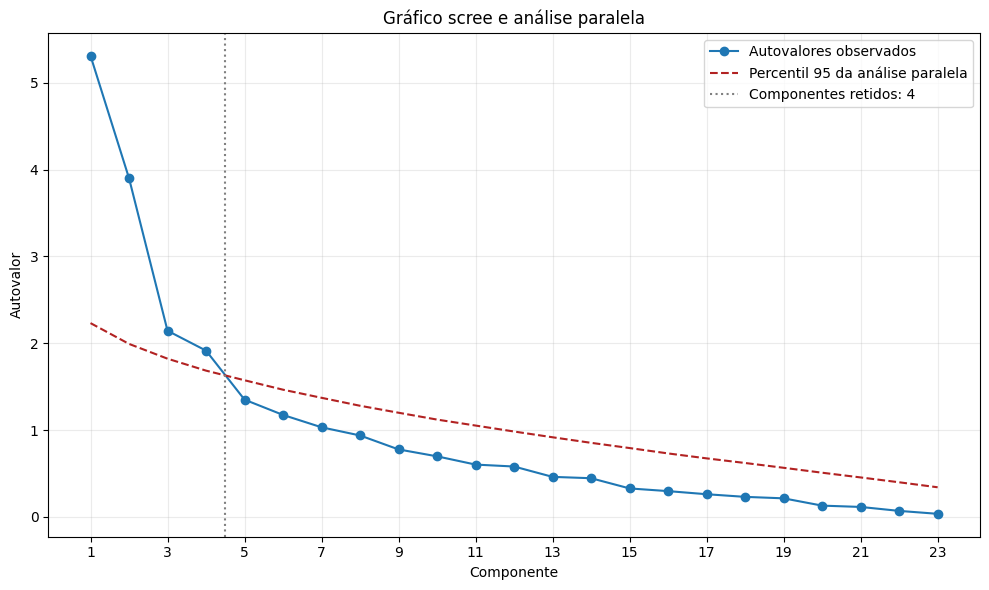

In [17]:
# Cria o gráfico que auxilia a visualização da retenção dos componentes.
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(1, p + 1), autovalores, marker="o", label="Autovalores observados")
ax.plot(np.arange(1, p + 1), limite_95, linestyle="--", color="firebrick",
        label="Percentil 95 da análise paralela")
ax.axvline(k + 0.5, linestyle=":", color="gray", label=f"Componentes retidos: {k}")
ax.set(title="Gráfico scree e análise paralela", xlabel="Componente", ylabel="Autovalor")
ax.set_xticks(np.arange(1, p + 1, 2))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()


## 12. Exportar tabelas e figura

Esta etapa grava os resultados em CSV, a figura em PNG e os parâmetros centrais em JSON. Ao final, cria um único arquivo ZIP e inicia o download para o computador.


In [18]:
# Salva as tabelas produzidas nas etapas anteriores.

def salvar_csv(tabela, nome, index=False):
    tabela.to_csv(PASTA_RESULTADOS / nome, index=index, encoding="utf-8-sig", float_format="%.10g")

salvar_csv(dados[["municipios_original", "municipio_id", *VARIAVEIS]], "dados_municipais.csv")
salvar_csv(estatisticas_descritivas, "estatisticas_descritivas.csv", index=True)
salvar_csv(pd.DataFrame(matriz_r, index=VARIAVEIS, columns=VARIAVEIS), "matriz_correlacoes.csv", index=True)
salvar_csv(msa_tabela, "kmo_msa.csv")
salvar_csv(tabela_autovalores, "autovalores_e_retencao.csv")
salvar_csv(tabela_cargas, "cargas_comunalidades.csv", index=True)
salvar_csv(tabela_escores, "escores_fatoriais.csv")
salvar_csv(pesos_tabela, "pesos_fatores.csv")
salvar_csv(resultado_ippra, "indice_ippra.csv")

# Exporta uma tabela curta que permite conferir a faixa de cada GI.
salvar_csv(resultado_ippra[["municipio_id", "GI", "menor_escore", "maior_escore", "GI_dentro_limites"]], "limites_gi.csv")

# Salva o gráfico para consulta e uso posterior.
fig.savefig(PASTA_RESULTADOS / "scree_analise_paralela.png", dpi=180, bbox_inches="tight")

# Registra configurações e medidas principais para identificar a execução.
metadados = {
    "seed": SEED,
    "arquivo_fonte": ARQUIVO_DADOS.name,
    "sha256_fonte": hashlib.sha256(ARQUIVO_DADOS.read_bytes()).hexdigest(),
    "aba": NOME_ABA,
    "n_municipios": int(n),
    "n_variaveis": int(p),
    "variaveis": VARIAVEIS,
    "siglas_repetidas": siglas_repetidas,
    "kmo": kmo_geral,
    "bartlett_chi2": float(bartlett_chi2),
    "bartlett_gl": int(bartlett_gl),
    "bartlett_p": bartlett_p,
    "componentes_retidos": int(k),
    "componentes_kaiser": int(np.sum(autovalores > 1)),
    "variancia_acumulada_percentual": float(variancia_acumulada[k - 1] * 100),
    "pesos_fatores": {nome: float(peso) for nome, peso in zip(nomes_fatores, pesos)},
    "simulacoes_analise_paralela": N_SIMULACOES,
    "versoes_bibliotecas": {
        "numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__,
        "openpyxl": __import__("openpyxl").__version__, "matplotlib": __import__("matplotlib").__version__,
    },
}
(PASTA_RESULTADOS / "resumo_execucao.json").write_text(
    json.dumps(metadados, ensure_ascii=False, indent=2), encoding="utf-8"
)

# Compacta todos os arquivos gerados e baixa o pacote de resultados.
CAMINHO_ZIP = Path("/content/resultados_ippra.zip")
if CAMINHO_ZIP.exists():
    CAMINHO_ZIP.unlink()
shutil.make_archive(str(CAMINHO_ZIP.with_suffix("")), "zip", root_dir=PASTA_RESULTADOS)
print("Arquivos gerados:", sorted(caminho.name for caminho in PASTA_RESULTADOS.iterdir()))
files.download(str(CAMINHO_ZIP))


Arquivos gerados: ['autovalores_e_retencao.csv', 'cargas_comunalidades.csv', 'dados_municipais.csv', 'escores_fatoriais.csv', 'estatisticas_descritivas.csv', 'indice_ippra.csv', 'kmo_msa.csv', 'limites_gi.csv', 'matriz_correlacoes.csv', 'pesos_fatores.csv', 'resumo_execucao.json', 'scree_analise_paralela.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>